# Algoritmos Ensemble y Optimizacion de Hiperparametros

```
CLASE 5                    CLASE 6                    CLASE 7 (HOY)
Validacion                 Clasificacion              Ensemble
    |                          |                          |
    v                          v                          v
Train/Test Split -------> Arbol de Decision -------> Random Forest
Cross-Validation          (un solo arbol)            (muchos arboles)
                                |                          |
                                |                          v
                                +--------------------> XGBoost
                                                       LightGBM
```

les queda como tarea aprender como funciona un arbol de decision.
por que vamos a combinar muchos arboles para crear modelos mas potentes.

---

# PARTE 1:Metodos Ensemble

---

## 1.1 Que es un Metodo Ensemble?

Un **ensemble** es una tecnica que combina multiples modelos "debiles" para crear un modelo "fuerte".

### Analogia: El Jurado

Imagina que tienes que decidir si un acusado es culpable o inocente:

```
OPCION A: Un solo juez decide

    [Juez] -----> Veredicto
    
    Problema: Si el juez tiene un sesgo o comete un error,
              el veredicto sera incorrecto.


OPCION B: Un jurado de 12 personas vota

    [Jurado 1]  --+
    [Jurado 2]  --+
    [Jurado 3]  --+
    [Jurado 4]  --+----> VOTACION -----> Veredicto
    [Jurado 5]  --+
       ...      --+
    [Jurado 12] --+
    
    Ventaja: Los errores individuales se cancelan entre si.
             La decision colectiva es mas confiable.
```

Los metodos ensemble funcionan igual: en lugar de confiar en un modelo,
combinamos muchos modelos y dejamos que "voten" o "promedien" su respuesta.

## 1.2 Bagging vs Boosting

Existen dos estrategias principales para crear ensembles:

```
============================================================================
                           BAGGING vs BOOSTING
============================================================================

BAGGING (Bootstrap Aggregating)          BOOSTING
--------------------------------          --------------------------------
Entrena modelos EN PARALELO              Entrena modelos EN SECUENCIA
Cada modelo ve datos diferentes          Cada modelo corrige al anterior
Los modelos son INDEPENDIENTES           Los modelos son DEPENDIENTES
Reduce VARIANZA (overfitting)            Reduce SESGO (underfitting)

Ejemplo: Random Forest                   Ejemplo: XGBoost, LightGBM

============================================================================
```

### Diagrama Visual de Bagging (Random Forest)

```
DATASET ORIGINAL
    |
    |----> Muestra 1 ----> [Arbol 1] ---+
    |                                    |
    |----> Muestra 2 ----> [Arbol 2] ---+
    |                                    +----> PROMEDIO/VOTO ----> Prediccion
    |----> Muestra 3 ----> [Arbol 3] ---+
    |                                    |
    +----> Muestra N ----> [Arbol N] ---+

Cada muestra es diferente (con reemplazo).
Cada arbol ve diferentes features.
Todos los arboles se entrenan AL MISMO TIEMPO.
```

### Diagrama Visual de Boosting (XGBoost)

```
DATASET
    |
    v
[Arbol 1] ----> Errores del Arbol 1
                        |
                        v
                [Arbol 2] ----> Errores del Arbol 2
                                        |
                                        v
                                [Arbol 3] ----> Errores del Arbol 3
                                                        |
                                                        v
                                                      (...)
                                                        |
                                                        v
PREDICCION FINAL = Arbol1 + Arbol2 + Arbol3 + ... + ArbolN

Cada arbol se enfoca en los ERRORES del anterior.
Los arboles se entrenan UNO DESPUES DEL OTRO.
```

## 1.3 Random Forest: El Bosque Aleatorio

### Como Funciona

Random Forest combina dos ideas:

1. **Bootstrap**: Cada arbol entrena con una muestra diferente del dataset
2. **Feature Sampling**: Cada arbol solo ve un subconjunto de features

```
DATASET: 1000 filas, 10 features

Arbol 1: Entrena con 1000 filas (algunas repetidas) + features [2,5,7]
Arbol 2: Entrena con 1000 filas (algunas repetidas) + features [1,3,9]
Arbol 3: Entrena con 1000 filas (algunas repetidas) + features [4,6,8]
...

Cada arbol es ligeramente diferente porque:
- Ve datos diferentes (bootstrap)
- Ve features diferentes (feature sampling)
```

### Por Que Funciona Tan Bien

```
UN SOLO ARBOL:                    RANDOM FOREST:

+------------------+              +------------------+
|  Alta Varianza   |              |  Baja Varianza   |
|  (Overfitting)   |              |  (Generaliza)    |
|                  |              |                  |
|  Pequenos        |              |  Los errores     |
|  cambios en      |      vs      |  se cancelan     |
|  datos = gran    |              |  entre arboles   |
|  cambio en       |              |                  |
|  prediccion      |              |                  |
+------------------+              +------------------+
```

### Hiperparametros Clave de Random Forest

| Parametro | Que controla | Valor tipico |
|-----------|--------------|---------------|
| n_estimators | Numero de arboles | 100-500 |
| max_depth | Profundidad maxima de cada arbol | 10-30 o None |
| min_samples_split | Minimo de muestras para dividir un nodo | 2-10 |
| min_samples_leaf | Minimo de muestras en una hoja | 1-5 |
| max_features | Features a considerar en cada division | 'sqrt' o 'log2' |

## 1.4 Gradient Boosting: XGBoost y LightGBM

### La Idea Central del Boosting

En lugar de entrenar arboles independientes, cada nuevo arbol
se enfoca en **corregir los errores** del modelo acumulado.

```
Iteracion 1:
    Prediccion = Arbol_1(X)
    Error_1 = Y_real - Prediccion

Iteracion 2:
    Arbol_2 aprende a predecir Error_1
    Prediccion = Arbol_1(X) + Arbol_2(X)
    Error_2 = Y_real - Prediccion

Iteracion 3:
    Arbol_3 aprende a predecir Error_2
    Prediccion = Arbol_1(X) + Arbol_2(X) + Arbol_3(X)
    ...

Prediccion Final = Suma de todos los arboles
```

### XGBoost vs LightGBM vs CatBoost

```
+-------------+------------------+------------------+------------------+
|             |     XGBoost      |     LightGBM     |     CatBoost     |
+-------------+------------------+------------------+------------------+
| Velocidad   | Medio            | Muy rapido       | Rapido           |
| Memoria     | Alta             | Baja             | Media            |
| Categoricas | Manual encoding  | Nativo           | Nativo (mejor)   |
| Precision   | Excelente        | Excelente        | Excelente        |
| Uso tipico  | Kaggle, general  | Big data         | Datos mixtos     |
+-------------+------------------+------------------+------------------+
```

### Hiperparametros Clave de XGBoost

| Parametro | Que controla | Valor tipico |
|-----------|--------------|---------------|
| n_estimators | Numero de arboles (iteraciones) | 100-1000 |
| learning_rate | Cuanto contribuye cada arbol | 0.01-0.3 |
| max_depth | Profundidad de cada arbol | 3-10 |
| subsample | Fraccion de datos por arbol | 0.7-1.0 |
| colsample_bytree | Fraccion de features por arbol | 0.7-1.0 |
| reg_alpha | Regularizacion L1 | 0-1 |
| reg_lambda | Regularizacion L2 | 0-1 |

## 1.5 Resumen Visual: Cuando Usar Cada Algoritmo

```
                        Tengo un problema de ML
                                  |
                                  v
                    Necesito interpretabilidad?
                         /              \
                       SI                NO
                       |                  |
                       v                  v
              Random Forest         Dataset grande?
              (+ facil de              /        \
               explicar)             SI          NO
                                     |           |
                                     v           v
                               LightGBM      XGBoost
                               (+ rapido)    (+ preciso)


REGLA PRACTICA:

1. Empieza con Random Forest (facil, robusto, pocos hiperparametros)
2. Si necesitas mas precision: prueba XGBoost
3. Si el dataset es muy grande: usa LightGBM
4. Si tienes muchas variables categoricas: considera CatBoost
```

---

# PARTE 2: Configuracion del Entorno

---

In [2]:
# =============================================================================
# INSTALACION DE LIBRERIAS
# =============================================================================
# En Google Colab, algunas librerias ya vienen instaladas (sklearn, pandas).
# Pero XGBoost, LightGBM y Optuna necesitan instalarse.

# Instalamos las librerias que no vienen por defecto en Colab
!pip install xgboost lightgbm optuna

In [3]:
# =============================================================================
# IMPORTACION DE LIBRERIAS
# =============================================================================

# --- Librerias para manipulacion de datos ---
import pandas as pd                    # Manejo de DataFrames (tablas)
import numpy as np                     # Operaciones numericas y arrays

# --- Librerias para visualizacion ---
import matplotlib.pyplot as plt        # Graficos basicos
import seaborn as sns                  # Graficos estadisticos mas bonitos

# --- Scikit-learn: Machine Learning clasico ---
from sklearn.model_selection import (
    train_test_split,                  # Dividir datos en train/test
    cross_val_score,                   # Validacion cruzada automatica
    GridSearchCV,                      # Busqueda exhaustiva de hiperparametros
    RandomizedSearchCV                 # Busqueda aleatoria de hiperparametros
)
from sklearn.ensemble import (
    RandomForestRegressor,             # Random Forest para regresion
    RandomForestClassifier,            # Random Forest para clasificacion
    GradientBoostingRegressor          # Gradient Boosting de sklearn
)
from sklearn.tree import DecisionTreeRegressor  # Arbol individual (para comparar)
from sklearn.linear_model import LinearRegression  # Regresion lineal (baseline)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error,                # Error cuadratico medio
    mean_absolute_error,               # Error absoluto medio
    r2_score                           # Coeficiente de determinacion
)

# --- Librerias de Gradient Boosting avanzado ---
import xgboost as xgb                  # XGBoost: el mas usado en competencias
import lightgbm as lgb                 # LightGBM: el mas rapido

# --- Optuna: Optimizacion bayesiana de hiperparametros ---
import optuna                          # Framework de optimizacion
from optuna.samplers import TPESampler # Sampler bayesiano

# --- Utilidades ---
import time                            # Para medir tiempos de ejecucion
import warnings
warnings.filterwarnings('ignore')      # Ignorar warnings para limpieza

# Configuracion de graficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Todas las librerias importadas correctamente')
print(f'XGBoost version: {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')
print(f'Optuna version: {optuna.__version__}')

Todas las librerias importadas correctamente
XGBoost version: 3.2.0
LightGBM version: 4.6.0
Optuna version: 4.8.0


---

# PARTE 3: Carga y Preparacion de Datos

---

Usaremos el dataset de ventas que limpiamos en clases anteriores.
Si no lo tienes, el codigo siguiente genera datos sinteticos similares.

In [4]:
# =============================================================================
# CARGAR O GENERAR DATOS
# =============================================================================

# Intentamos cargar el dataset de ventas de clases anteriores
# Si no existe, generamos datos sinteticos para la practica

try:
    # Intenta cargar el archivo (ajusta la ruta si es necesario)
    df = pd.read_csv('ventas_200k.csv')
    print('Dataset cargado desde archivo')

except FileNotFoundError:
    # Si no existe el archivo, generamos datos sinteticos
    print('Generando datos sinteticos para la practica...')

    np.random.seed(42)  # Semilla para reproducibilidad
    n_samples = 50000   # 50 mil registros

    # Generamos features que simulan datos de ventas
    df = pd.DataFrame({
        # Precio unitario: entre 10 y 500
        'precio': np.random.uniform(10, 500, n_samples),

        # Cantidad: entre 1 y 20 unidades
        'cantidad': np.random.randint(1, 21, n_samples),

        # Costo: 40-80% del precio
        'costo': np.random.uniform(0.4, 0.8, n_samples),

        # Descuento: 0-30%
        'descuento': np.random.uniform(0, 0.30, n_samples),

        # Mes: 1-12
        'mes': np.random.randint(1, 13, n_samples),

        # Dia de la semana: 0=Lunes, 6=Domingo
        'dia_semana': np.random.randint(0, 7, n_samples),

        # Trimestre: 1-4
        'trimestre': np.random.randint(1, 5, n_samples),

        # Categoria: 0=Electronica, 1=Ropa, 2=Hogar, 3=Alimentos
        'categoria': np.random.randint(0, 4, n_samples),

        # Region: 0=Norte, 1=Sur, 2=Este, 3=Oeste
        'region': np.random.randint(0, 4, n_samples)
    })

    # Calculamos el costo real
    df['costo'] = df['precio'] * df['costo']

    # Variable binaria: es fin de semana?
    df['es_finde'] = (df['dia_semana'] >= 5).astype(int)

    # Calculamos el monto (variable objetivo)
    # Formula: precio * cantidad * (1 - descuento) + ruido
    df['monto'] = (
        df['precio'] * df['cantidad'] * (1 - df['descuento'])
        + np.random.normal(0, 50, n_samples)  # Ruido aleatorio
    )

    # Aseguramos que el monto sea positivo
    df['monto'] = df['monto'].clip(lower=10)

    print('Datos sinteticos generados')

# Mostramos informacion del dataset
print(f'\nShape del dataset: {df.shape}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Generando datos sinteticos para la practica...
Datos sinteticos generados

Shape del dataset: (50000, 11)
Filas: 50,000 | Columnas: 11


,precio,cantidad,costo,descuento,mes,dia_semana,trimestre,categoria,region,es_finde,monto
0,193.524658,9,140.151777,0.243896,5,6,2,1,2,1,1310.921621
1,475.850010,4,346.833645,0.078864,2,2,2,0,1,0,1800.391158
2,368.677031,6,181.424842,0.177790,2,3,1,2,3,0,1802.814623
3,303.342657,2,220.451080,0.078730,4,3,3,0,2,0,582.689269
4,86.449134,1,47.170112,0.145109,9,0,2,2,3,0,51.473660


In [5]:
# =============================================================================
# PREPARAR DATOS PARA MACHINE LEARNING
# =============================================================================

# Definimos las features (X) y la variable objetivo (y)
#
# IMPORTANTE: Solo usamos columnas numericas.
# Si tienes columnas categoricas como texto, debes convertirlas
# con LabelEncoder o pd.get_dummies() primero.

# Lista de features a usar
# (ajusta segun las columnas de tu dataset)
feature_cols = ['precio', 'cantidad', 'costo', 'descuento',
                'mes', 'dia_semana', 'trimestre', 'categoria',
                'region', 'es_finde']

# Filtramos solo las columnas que existen en nuestro dataset
feature_cols = [col for col in feature_cols if col in df.columns]

print('Features a utilizar:')
print(feature_cols)

# Creamos X (features) e y (objetivo)
X = df[feature_cols].copy()
y = df['monto'].copy()

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')

Features a utilizar:
['precio', 'cantidad', 'costo', 'descuento', 'mes', 'dia_semana', 'trimestre', 'categoria', 'region', 'es_finde']

X shape: (50000, 10)
y shape: (50000,)


In [6]:
# =============================================================================
# DIVIDIR EN TRAIN Y TEST
# =============================================================================

# Dividimos los datos:
# - 80% para entrenamiento (train)
# - 20% para evaluacion (test)
#
# random_state=42: Semilla para que siempre obtengamos la misma division
#                  Esto hace que los resultados sean reproducibles

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                    # Datos a dividir
    test_size=0.2,           # 20% para test
    random_state=42          # Semilla para reproducibilidad
)

print('Division de datos completada:')
print(f'  Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)')

Division de datos completada:
  Train: 40,000 filas (80%)
  Test:  10,000 filas (20%)


---

# PARTE 4: Implementacion de Modelos Ensemble

---

Vamos a entrenar y comparar varios modelos:

1. Regresion Lineal (baseline)
2. Arbol de Decision (un solo arbol)
3. Random Forest (bagging)
4. XGBoost (boosting)
5. LightGBM (boosting rapido)

In [7]:
# =============================================================================
# FUNCION PARA EVALUAR MODELOS
# =============================================================================

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre):
    """
    Entrena un modelo, hace predicciones y calcula metricas.

    Parametros:
    -----------
    modelo : objeto sklearn/xgboost/lightgbm
        El modelo a entrenar (ya instanciado pero no entrenado)
    X_train, X_test : DataFrame
        Features de entrenamiento y test
    y_train, y_test : Series
        Variable objetivo de entrenamiento y test
    nombre : str
        Nombre del modelo para mostrar en resultados

    Retorna:
    --------
    dict : Diccionario con nombre, metricas y tiempo de entrenamiento
    """

    # Medimos el tiempo de entrenamiento
    inicio = time.time()

    # Entrenamos el modelo
    modelo.fit(X_train, y_train)

    # Calculamos el tiempo transcurrido
    tiempo_train = time.time() - inicio

    # Hacemos predicciones en el conjunto de test
    y_pred = modelo.predict(X_test)

    # Calculamos metricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Mostramos resultados
    print(f'\n{"="*60}')
    print(f'{nombre}')
    print(f'{"="*60}')
    print(f'Tiempo de entrenamiento: {tiempo_train:.2f} segundos')
    print(f'R2 Score:  {r2:.4f}  (1.0 = perfecto)')
    print(f'RMSE:      {rmse:.2f}  (menor es mejor)')
    print(f'MAE:       {mae:.2f}  (menor es mejor)')

    return {
        'nombre': nombre,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'tiempo': tiempo_train,
        'modelo': modelo
    }

In [8]:
# =============================================================================
# MODELO BASELINE - REGRESION LINEAL
# =============================================================================

# La regresion lineal es nuestro "baseline" (punto de referencia).
# Cualquier modelo ensemble deberia superar a la regresion lineal,
# de lo contrario no vale la pena la complejidad adicional.

modelo_lr = LinearRegression()

resultado_lr = evaluar_modelo(
    modelo_lr,
    X_train, X_test,
    y_train, y_test,
    'Regresion Lineal (Baseline)'
)


Regresion Lineal (Baseline)
Tiempo de entrenamiento: 0.05 segundos
R2 Score:  0.8608  (1.0 = perfecto)
RMSE:      723.02  (menor es mejor)
MAE:       535.80  (menor es mejor)


In [9]:
# =============================================================================
# ARBOL DE DECISION INDIVIDUAL
# =============================================================================

# Un solo arbol de decision.
# Este es el "ingrediente" de Random Forest.
# Veremos como un solo arbol tiene alta varianza (overfitting).

modelo_tree = DecisionTreeRegressor(
    max_depth=15,        # Limitamos profundidad para evitar overfitting extremo
    random_state=42
)

resultado_tree = evaluar_modelo(
    modelo_tree,
    X_train, X_test,
    y_train, y_test,
    'Arbol de Decision (Individual)'
)


Arbol de Decision (Individual)
Tiempo de entrenamiento: 0.45 segundos
R2 Score:  0.9975  (1.0 = perfecto)
RMSE:      96.46  (menor es mejor)
MAE:       73.50  (menor es mejor)


In [10]:
# =============================================================================
# RANDOM FOREST
# =============================================================================

# Random Forest combina multiples arboles de decision.
# Cada arbol ve datos y features ligeramente diferentes.
# La prediccion final es el PROMEDIO de todos los arboles.

modelo_rf = RandomForestRegressor(
    n_estimators=100,    # Numero de arboles en el bosque
                         # Mas arboles = mejor pero mas lento
                         # 100-500 es un buen rango

    max_depth=15,        # Profundidad maxima de cada arbol
                         # None = sin limite (puede causar overfitting)
                         # 10-30 es un buen rango

    min_samples_split=5, # Minimo de muestras para dividir un nodo
                         # Valores altos previenen overfitting

    min_samples_leaf=2,  # Minimo de muestras en cada hoja
                         # Valores altos crean arboles mas simples

    max_features='sqrt', # Features a considerar en cada division
                         # 'sqrt' = raiz cuadrada del total
                         # Introduce aleatoriedad entre arboles

    n_jobs=-1,           # Usar todos los nucleos del CPU
                         # -1 = todos disponibles
                         # Acelera el entrenamiento significativamente

    random_state=42      # Semilla para reproducibilidad
)

resultado_rf = evaluar_modelo(
    modelo_rf,
    X_train, X_test,
    y_train, y_test,
    'Random Forest (100 arboles)'
)


Random Forest (100 arboles)
Tiempo de entrenamiento: 6.81 segundos
R2 Score:  0.9938  (1.0 = perfecto)
RMSE:      152.46  (menor es mejor)
MAE:       107.04  (menor es mejor)


In [11]:
# =============================================================================
# XGBOOST
# =============================================================================

# XGBoost (eXtreme Gradient Boosting) es uno de los algoritmos
# mas exitosos en competencias de Machine Learning.
#
# A diferencia de Random Forest (arboles en paralelo),
# XGBoost entrena arboles en SECUENCIA, donde cada nuevo arbol
# intenta corregir los errores del modelo acumulado.

modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,     # Numero de arboles (iteraciones de boosting)
                          # Mas = mejor pero puede causar overfitting

    learning_rate=0.1,    # Tasa de aprendizaje (shrinkage)
                          # Controla cuanto contribuye cada arbol
                          # Valores bajos (0.01-0.1) requieren mas arboles
                          # pero generalizan mejor

    max_depth=6,          # Profundidad de cada arbol
                          # En boosting se usan arboles MAS PEQUENOS
                          # que en bagging (tipicamente 3-10)

    subsample=0.8,        # Fraccion de datos para cada arbol
                          # <1.0 introduce estocasticidad
                          # Ayuda a prevenir overfitting

    colsample_bytree=0.8, # Fraccion de features para cada arbol
                          # Similar a max_features en Random Forest

    reg_alpha=0.1,        # Regularizacion L1 (Lasso)
                          # Penaliza la complejidad del modelo

    reg_lambda=1.0,       # Regularizacion L2 (Ridge)
                          # Tambien penaliza la complejidad

    n_jobs=-1,            # Paralelizacion
    random_state=42,
    verbosity=0           # Silenciar mensajes de XGBoost
)

resultado_xgb = evaluar_modelo(
    modelo_xgb,
    X_train, X_test,
    y_train, y_test,
    'XGBoost'
)


XGBoost
Tiempo de entrenamiento: 1.25 segundos
R2 Score:  0.9989  (1.0 = perfecto)
RMSE:      65.36  (menor es mejor)
MAE:       51.47  (menor es mejor)


In [12]:
# =============================================================================
# LIGHTGBM
# =============================================================================

# LightGBM (Light Gradient Boosting Machine) fue desarrollado por Microsoft.
# Es muy similar a XGBoost pero con optimizaciones que lo hacen:
#   - Mucho mas RAPIDO (especialmente con datasets grandes)
#   - Usa menos MEMORIA
#   - Maneja variables categoricas de forma NATIVA

modelo_lgb = lgb.LGBMRegressor(
    n_estimators=100,     # Numero de arboles

    learning_rate=0.1,    # Tasa de aprendizaje

    max_depth=6,          # Profundidad maxima
                          # -1 = sin limite

    num_leaves=31,        # Numero maximo de hojas por arbol
                          # PARAMETRO CLAVE de LightGBM
                          # Debe ser < 2^max_depth
                          # Controla la complejidad del arbol

    subsample=0.8,        # Fraccion de datos (llamado bagging_fraction)

    colsample_bytree=0.8, # Fraccion de features (feature_fraction)

    reg_alpha=0.1,        # Regularizacion L1
    reg_lambda=1.0,       # Regularizacion L2

    n_jobs=-1,
    random_state=42,
    verbosity=-1          # Silenciar mensajes
)

resultado_lgb = evaluar_modelo(
    modelo_lgb,
    X_train, X_test,
    y_train, y_test,
    'LightGBM'
)


LightGBM
Tiempo de entrenamiento: 0.43 segundos
R2 Score:  0.9988  (1.0 = perfecto)
RMSE:      67.13  (menor es mejor)
MAE:       53.03  (menor es mejor)


---

# PARTE 5: Comparacion de Modelos

---

In [14]:
# =============================================================================
# TABLA COMPARATIVA DE RESULTADOS
# =============================================================================

# Recopilamos todos los resultados en una lista
resultados = [
    resultado_lr,
    resultado_tree,
    resultado_rf,
    resultado_xgb,
    resultado_lgb
]

# Creamos un DataFrame con los resultados
df_resultados = pd.DataFrame(resultados)

# Seleccionamos y ordenamos columnas
df_resultados = df_resultados[['nombre', 'r2', 'rmse', 'mae', 'tiempo']]

# Ordenamos por R2 (mayor es mejor)
df_resultados = df_resultados.sort_values('r2', ascending=False)

# Formateamos para mejor visualizacion
print('\n' + '='*80)
print('COMPARACION DE MODELOS')
print('='*80)
print(df_resultados.to_string(index=False))
print('='*80)


COMPARACION DE MODELOS
                        nombre       r2       rmse        mae   tiempo
                       XGBoost 0.998863  65.359109  51.470492 1.253961
                      LightGBM 0.998800  67.126619  53.026199 0.434724
Arbol de Decision (Individual) 0.997523  96.463168  73.498038 0.450238
   Random Forest (100 arboles) 0.993812 152.462314 107.040347 6.805000
   Regresion Lineal (Baseline) 0.860831 723.021036 535.804474 0.050813


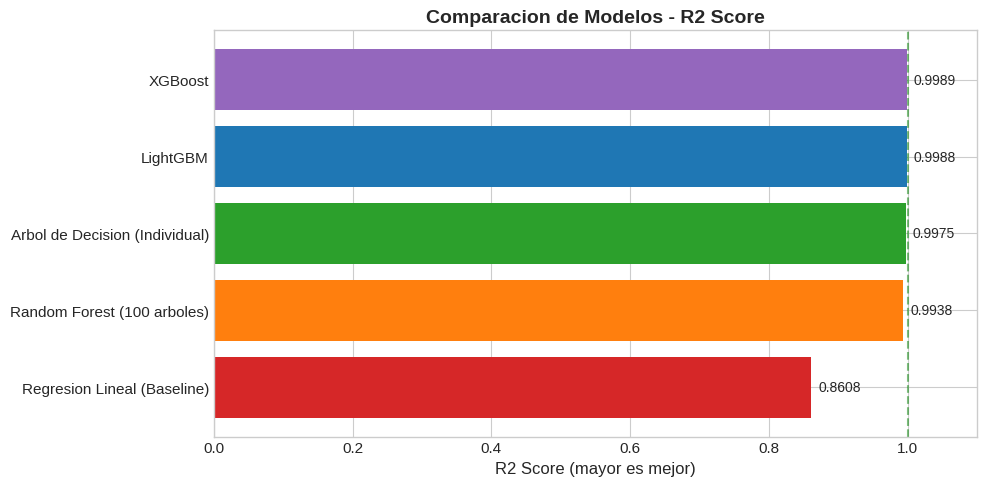

In [15]:
# =============================================================================
# GRAFICO COMPARATIVO DE R2
# =============================================================================

# Creamos un grafico de barras horizontal para comparar R2

fig, ax = plt.subplots(figsize=(10, 5))

# Ordenamos por R2 para mejor visualizacion
df_plot = df_resultados.sort_values('r2', ascending=True)

# Colores: verde para los mejores, rojo para los peores
colores = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

# Grafico de barras horizontales
barras = ax.barh(df_plot['nombre'], df_plot['r2'], color=colores)

# Anadimos los valores en las barras
for barra, valor in zip(barras, df_plot['r2']):
    ax.text(valor + 0.01, barra.get_y() + barra.get_height()/2,
            f'{valor:.4f}', va='center', fontsize=10)

ax.set_xlabel('R2 Score (mayor es mejor)', fontsize=12)
ax.set_title('Comparacion de Modelos - R2 Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)

# Linea vertical en R2=1 (modelo perfecto)
ax.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Perfecto (R2=1)')

plt.tight_layout()
plt.show()

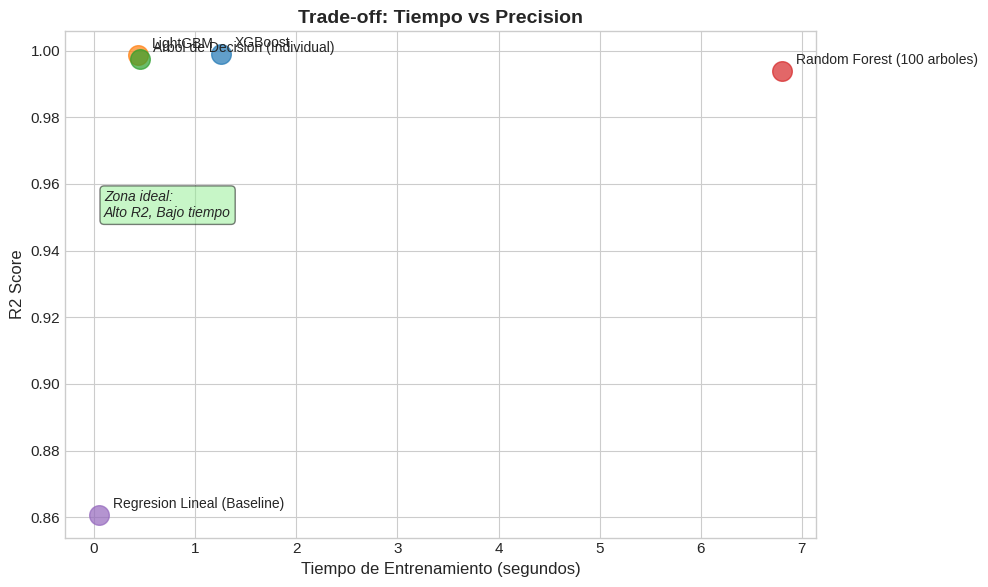

In [16]:
# =============================================================================
# GRAFICO DE TIEMPO VS PRECISION
# =============================================================================

# Este grafico muestra el trade-off entre tiempo de entrenamiento y precision.
# Idealmente queremos modelos en la esquina superior izquierda:
# alta precision (R2 alto) y bajo tiempo de entrenamiento.

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
for i, row in df_resultados.iterrows():
    ax.scatter(row['tiempo'], row['r2'], s=200, alpha=0.7)
    ax.annotate(row['nombre'],
                (row['tiempo'], row['r2']),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=10)

ax.set_xlabel('Tiempo de Entrenamiento (segundos)', fontsize=12)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('Trade-off: Tiempo vs Precision', fontsize=14, fontweight='bold')

# Anotacion de la zona ideal
ax.annotate('Zona ideal:\nAlto R2, Bajo tiempo',
            xy=(0.1, 0.95), fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

---

# PARTE 6: Feature Importance (Importancia de Variables)

---

Una gran ventaja de los modelos basados en arboles es que nos dicen
**que tan importante es cada feature** para hacer predicciones.

```
Que significa "importancia"?

Para Random Forest:
    La importancia se mide por cuanto REDUCE el error
    cada feature cuando se usa para dividir los nodos.
    
    Feature que reduce mucho el error = Alta importancia
    Feature que reduce poco el error = Baja importancia

Para XGBoost/LightGBM:
    Hay varias formas de medir importancia:
    - Gain: Reduccion promedio de la funcion de perdida
    - Cover: Numero de muestras afectadas
    - Frequency: Cuantas veces se uso la feature
```

In [17]:
# =============================================================================
# FEATURE IMPORTANCE DE RANDOM FOREST
# =============================================================================

# Obtenemos la importancia de cada feature del modelo Random Forest
# El atributo .feature_importances_ contiene un array con las importancias

importancias_rf = modelo_rf.feature_importances_

# Creamos un DataFrame para visualizar mejor
df_importancia_rf = pd.DataFrame({
    'feature': feature_cols,
    'importancia': importancias_rf
}).sort_values('importancia', ascending=False)

print('IMPORTANCIA DE FEATURES - Random Forest')
print('='*50)
for _, row in df_importancia_rf.iterrows():
    # Creamos una barra visual con caracteres
    barra = '#' * int(row['importancia'] * 50)
    print(f"{row['feature']:15} | {row['importancia']:.4f} | {barra}")
print('='*50)

IMPORTANCIA DE FEATURES - Random Forest
cantidad        | 0.4829 | ########################
precio          | 0.3272 | ################
costo           | 0.1545 | #######
descuento       | 0.0258 | #
mes             | 0.0028 | 
dia_semana      | 0.0020 | 
region          | 0.0016 | 
trimestre       | 0.0015 | 
categoria       | 0.0015 | 
es_finde        | 0.0004 | 


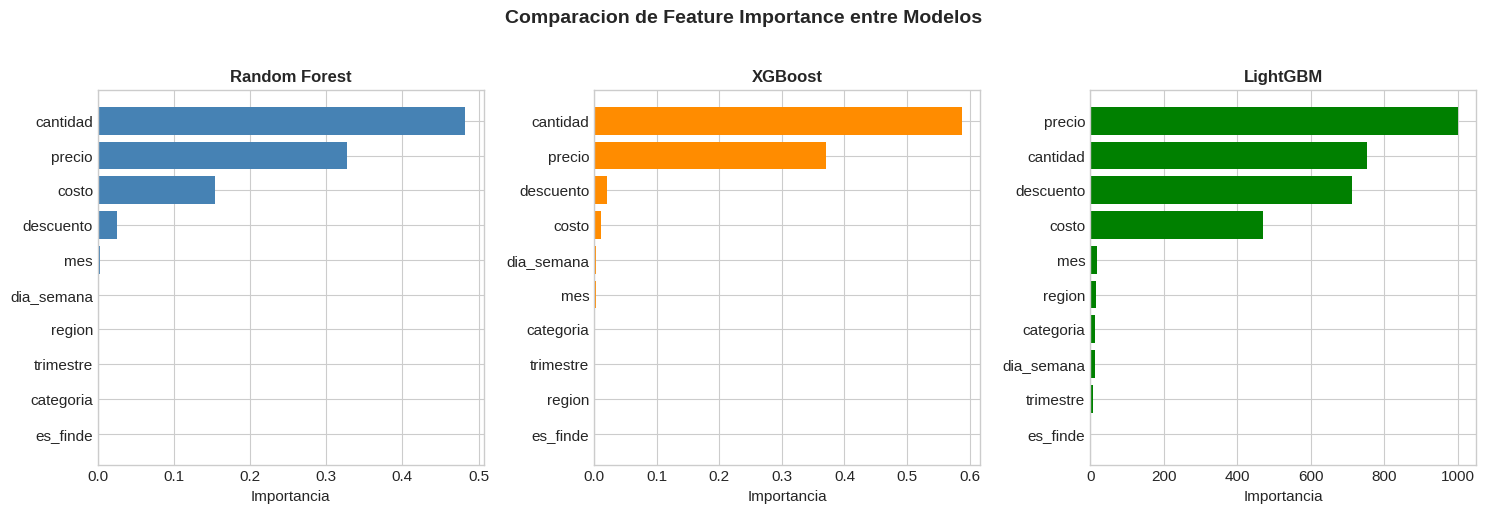

In [18]:
# =============================================================================
# GRAFICO DE FEATURE IMPORTANCE COMPARATIVO
# =============================================================================

# Comparamos la importancia de features entre los 3 modelos ensemble

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Random Forest ---
df_imp_rf = pd.DataFrame({
    'feature': feature_cols,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=True)

axes[0].barh(df_imp_rf['feature'], df_imp_rf['importancia'], color='steelblue')
axes[0].set_title('Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia')

# --- XGBoost ---
df_imp_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=True)

axes[1].barh(df_imp_xgb['feature'], df_imp_xgb['importancia'], color='darkorange')
axes[1].set_title('XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importancia')

# --- LightGBM ---
df_imp_lgb = pd.DataFrame({
    'feature': feature_cols,
    'importancia': modelo_lgb.feature_importances_
}).sort_values('importancia', ascending=True)

axes[2].barh(df_imp_lgb['feature'], df_imp_lgb['importancia'], color='green')
axes[2].set_title('LightGBM', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importancia')

plt.suptitle('Comparacion de Feature Importance entre Modelos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretacion de Feature Importance

```
COMO INTERPRETAR ESTOS GRAFICOS:

1. Las features en la parte SUPERIOR son las MAS IMPORTANTES
   - El modelo depende mucho de ellas para hacer predicciones
   - Son las que mas informacion aportan

2. Las features en la parte INFERIOR son las MENOS IMPORTANTES
   - Podriamos eliminarlas sin perder mucha precision
   - Esto simplifica el modelo y reduce overfitting

3. Si los 3 modelos coinciden en las features importantes:
   - Esas features son genuinamente predictivas
   - Tienen una relacion real con la variable objetivo

4. Si los modelos NO coinciden:
   - Puede haber multicolinealidad (features correlacionadas)
   - Diferentes algoritmos capturan diferentes patrones

APLICACION PRACTICA:

- Para el proyecto final, usa feature importance para:
  1. Identificar las variables clave de tu negocio
  2. Eliminar features irrelevantes
  3. Explicar el modelo a stakeholders no tecnicos
```

---

# PARTE 7: Optimizacion de Hiperparametros

---

Hasta ahora usamos hiperparametros "por defecto" o basados en experiencia.
Ahora aprenderemos a encontrar los MEJORES hiperparametros de forma sistematica.

```
METODOS DE OPTIMIZACION DE HIPERPARAMETROS:

+------------------+------------------+------------------+------------------+
|     Metodo       |    Como busca    |     Ventaja      |    Desventaja    |
+------------------+------------------+------------------+------------------+
| Grid Search      | Prueba TODAS las | Exhaustivo,      | MUY LENTO si     |
|                  | combinaciones    | encuentra el     | hay muchos       |
|                  |                  | optimo           | parametros       |
+------------------+------------------+------------------+------------------+
| Random Search    | Prueba combina-  | Mas rapido que   | Puede perder     |
|                  | ciones ALEATORIAS| Grid Search      | el optimo        |
+------------------+------------------+------------------+------------------+
| Bayesian (Optuna)| Aprende de       | El mas           | Mas complejo     |
|                  | resultados       | EFICIENTE        | de implementar   |
|                  | anteriores       |                  |                  |
+------------------+------------------+------------------+------------------+
```

In [19]:
# =============================================================================
# GRID SEARCH - BUSQUEDA EXHAUSTIVA
# =============================================================================

# Grid Search prueba TODAS las combinaciones de hiperparametros.
# Es exhaustivo pero puede ser muy lento.

print('GRID SEARCH - Random Forest')
print('='*60)

# Definimos la grilla de hiperparametros a probar
# IMPORTANTE: Mantener la grilla pequena para que no tarde demasiado
param_grid = {
    'n_estimators': [50, 100],       # 2 valores
    'max_depth': [10, 15, 20],        # 3 valores
    'min_samples_split': [2, 5],      # 2 valores
    'min_samples_leaf': [1, 2]        # 2 valores
}

# Calculamos el numero total de combinaciones
n_combinaciones = 2 * 3 * 2 * 2
print(f'Combinaciones a probar: {n_combinaciones}')
print(f'Con 3-fold CV: {n_combinaciones * 3} entrenamientos totales')
print('\nEsto puede tardar unos minutos...\n')

# Creamos el objeto GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,                    # 3-fold cross-validation
    scoring='r2',            # Metrica a optimizar
    n_jobs=-1,               # Paralelizar
    verbose=1                # Mostrar progreso
)

# Ejecutamos la busqueda
inicio = time.time()
grid_search.fit(X_train, y_train)
tiempo_grid = time.time() - inicio

# Mostramos resultados
print(f'\nTiempo total: {tiempo_grid:.1f} segundos')
print(f'\nMejores hiperparametros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMejor R2 (CV): {grid_search.best_score_:.4f}')

GRID SEARCH - Random Forest
Combinaciones a probar: 24
Con 3-fold CV: 72 entrenamientos totales

Esto puede tardar unos minutos...

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Tiempo total: 777.6 segundos

Mejores hiperparametros encontrados:
  max_depth: 20
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100

Mejor R2 (CV): 0.9988


In [20]:
# =============================================================================
# EVALUAR EL MEJOR MODELO DE GRID SEARCH
# =============================================================================

# El mejor modelo encontrado por Grid Search esta en .best_estimator_
mejor_modelo_grid = grid_search.best_estimator_

# Evaluamos en el conjunto de test
y_pred_grid = mejor_modelo_grid.predict(X_test)
r2_grid = r2_score(y_test, y_pred_grid)
rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred_grid))

print('EVALUACION DEL MEJOR MODELO (Grid Search)')
print('='*50)
print(f'R2 en Test:  {r2_grid:.4f}')
print(f'RMSE en Test: {rmse_grid:.2f}')

# Comparamos con el Random Forest original
print(f'\nMejora vs RF original:')
print(f'  R2 original:   {resultado_rf["r2"]:.4f}')
print(f'  R2 optimizado: {r2_grid:.4f}')
print(f'  Diferencia:    {(r2_grid - resultado_rf["r2"])*100:.2f}%')

EVALUACION DEL MEJOR MODELO (Grid Search)
R2 en Test:  0.9990
RMSE en Test: 62.16

Mejora vs RF original:
  R2 original:   0.9938
  R2 optimizado: 0.9990
  Diferencia:    0.52%


In [21]:
# =============================================================================
# OPTUNA - OPTIMIZACION BAYESIANA
# =============================================================================

# Optuna es un framework moderno de optimizacion de hiperparametros.
# A diferencia de Grid Search (que prueba todo), Optuna APRENDE
# de los resultados anteriores para elegir mejores combinaciones.
#
# Es como un jugador de ajedrez que mejora con cada partida,
# en lugar de probar todos los movimientos posibles.

print('OPTUNA - Optimizacion Bayesiana')
print('='*60)

def objetivo_optuna(trial):
    """
    Funcion objetivo que Optuna intentara MAXIMIZAR.

    trial: Objeto de Optuna que sugiere hiperparametros.
           Cada trial es un intento con diferentes parametros.
    """

    # Optuna sugiere valores para cada hiperparametro
    # suggest_int: para enteros
    # suggest_float: para decimales
    # suggest_categorical: para elegir entre opciones

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    # Creamos el modelo con los parametros sugeridos
    modelo = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    # Evaluamos con cross-validation (3 folds para rapidez)
    scores = cross_val_score(modelo, X_train, y_train, cv=3, scoring='r2')

    # Retornamos el promedio de R2
    return scores.mean()

# Creamos el estudio de Optuna
# direction='maximize' porque queremos maximizar R2
estudio = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)  # TPE = Tree-structured Parzen Estimator
)

# Silenciamos los mensajes de Optuna para mayor claridad
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Ejecutando 30 trials (puede tardar unos minutos)...\n')

# Ejecutamos la optimizacion
inicio = time.time()
estudio.optimize(
    objetivo_optuna,
    n_trials=30,      # Numero de combinaciones a probar
    show_progress_bar=True
)
tiempo_optuna = time.time() - inicio

print(f'\nTiempo total: {tiempo_optuna:.1f} segundos')
print(f'\nMejores hiperparametros encontrados:')
for param, valor in estudio.best_params.items():
    print(f'  {param}: {valor}')
print(f'\nMejor R2 (CV): {estudio.best_value:.4f}')

[I 2026-04-08 14:53:34,309] A new study created in memory with name: no-name-a0f6b3d1-70d6-49b2-b8e7-898a2c64fd32


OPTUNA - Optimizacion Bayesiana
Ejecutando 30 trials (puede tardar unos minutos)...



  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-04-08 14:59:10,383] Trial 12 failed with parameters: {'n_estimators': 154, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': None} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3143/3565449433.py", line 44, in objetivo_optuna
    scores = cross_val_score(modelo, X_train, y_train, cv=3, scoring='r2')
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
# =============================================================================
# EVALUAR EL MEJOR MODELO DE OPTUNA
# =============================================================================

# Creamos el modelo con los mejores parametros de Optuna
mejor_modelo_optuna = RandomForestRegressor(
    **estudio.best_params,
    random_state=42,
    n_jobs=-1
)

# Entrenamos con todos los datos de train
mejor_modelo_optuna.fit(X_train, y_train)

# Evaluamos en test
y_pred_optuna = mejor_modelo_optuna.predict(X_test)
r2_optuna = r2_score(y_test, y_pred_optuna)
rmse_optuna = np.sqrt(mean_squared_error(y_test, y_pred_optuna))

print('EVALUACION DEL MEJOR MODELO (Optuna)')
print('='*50)
print(f'R2 en Test:  {r2_optuna:.4f}')
print(f'RMSE en Test: {rmse_optuna:.2f}')

In [ ]:
# =============================================================================
# COMPARACION FINAL DE METODOS DE OPTIMIZACION
# =============================================================================

print('\n' + '='*70)
print('COMPARACION: Grid Search vs Optuna vs Sin Optimizar')
print('='*70)

comparacion = pd.DataFrame([
    {'Metodo': 'RF Sin Optimizar', 'R2 Test': resultado_rf['r2'],
     'Tiempo (s)': resultado_rf['tiempo']},
    {'Metodo': 'RF + Grid Search', 'R2 Test': r2_grid,
     'Tiempo (s)': tiempo_grid},
    {'Metodo': 'RF + Optuna', 'R2 Test': r2_optuna,
     'Tiempo (s)': tiempo_optuna}
])

print(comparacion.to_string(index=False))
print('='*70)

---

# PARTE 8: Por Que Algunos Modelos Tardan Tanto?

---

Esta seccion explica **por que ciertos modelos tardan mucho** en entrenar
y como evitar esperas innecesarias.

```
FACTORES QUE AFECTAN EL TIEMPO DE ENTRENAMIENTO:

+------------------+--------------------------------------------------+
|     Factor       |                    Impacto                       |
+------------------+--------------------------------------------------+
| Tamano del       | Mas filas = mas calculos                         |
| dataset          | 10x filas puede ser 10x mas lento                |
+------------------+--------------------------------------------------+
| Numero de        | Cada feature adicional aumenta la complejidad    |
| features         | del espacio de busqueda                          |
+------------------+--------------------------------------------------+
| n_estimators     | Mas arboles = mas tiempo (lineal)                |
| (arboles)        | 1000 arboles tarda 10x mas que 100               |
+------------------+--------------------------------------------------+
| max_depth        | Arboles mas profundos = exponencialmente         |
|                  | mas nodos que evaluar                            |
+------------------+--------------------------------------------------+
| Grid Search      | Prueba TODAS las combinaciones                   |
| combinaciones    | 5 params x 5 valores = 3,125 modelos!            |
+------------------+--------------------------------------------------+
| Cross-Validation | Multiplica el tiempo por K                       |
|                  | 5-fold = 5x mas entrenamientos                   |
+------------------+--------------------------------------------------+
```

In [ ]:
# =============================================================================
# EJEMPLO DE MODELO LENTO - CONFIGURACION EXTREMA
# =============================================================================

# ADVERTENCIA: Esta celda tardara varios minutos en ejecutarse.
# El proposito es demostrar como ciertas configuraciones
# pueden hacer que un modelo tarde MUCHO tiempo.

print('='*70)
print('EJEMPLO: MODELO QUE TARDA MUCHO EN ENTRENAR')
print('='*70)
print('')
print('Vamos a entrenar un modelo con configuracion "costosa":')
print('')
print('  - 500 arboles (n_estimators=500)')
print('  - Sin limite de profundidad (max_depth=None)')
print('  - Minimo 1 muestra por hoja (min_samples_leaf=1)')
print('  - Evaluado con 5-fold Cross-Validation')
print('')
print('Por que tarda tanto?')
print('-' * 50)
print('')

# Explicacion detallada
explicacion = """
1. n_estimators=500:
   - Tenemos que entrenar 500 arboles completos
   - Cada arbol procesa los datos de forma independiente
   - Tiempo aproximado: 500 x tiempo_de_un_arbol

2. max_depth=None (sin limite):
   - Los arboles crecen hasta que cada hoja sea "pura"
   - Un arbol sin limite puede tener miles de nodos
   - Cada nodo requiere evaluar todas las features
   - Con profundidad 20, un arbol puede tener 2^20 = 1,048,576 hojas!

3. min_samples_leaf=1:
   - Permitimos hojas con una sola muestra
   - Esto maximiza el numero de divisiones
   - El arbol se vuelve extremadamente detallado

4. Cross-Validation con 5 folds:
   - Entrenamos el modelo 5 veces (una por fold)
   - Tiempo total = 5 x tiempo_de_entrenar_una_vez

CALCULO DEL TIEMPO:
   Si entrenar 100 arboles tarda 5 segundos:
   - 500 arboles = 25 segundos
   - Con 5-fold CV = 125 segundos (2 minutos)
   - Con max_depth=None puede ser 2-3x mas lento
   - Total estimado: 3-6 minutos
"""
print(explicacion)

In [ ]:
# =============================================================================
# EJECUTAR EL MODELO LENTO (CON MEDICION DE TIEMPO)
# =============================================================================

# Modelo con configuracion costosa
modelo_lento = RandomForestRegressor(
    n_estimators=500,       # Muchos arboles
    max_depth=None,         # Sin limite de profundidad
    min_samples_leaf=1,     # Hojas muy pequenas
    min_samples_split=2,    # Divisiones con 2 muestras
    n_jobs=-1,              # Usar todos los nucleos
    random_state=42
)

print('Iniciando entrenamiento del modelo lento...')
print('(Esto puede tardar varios minutos)\n')

# Medimos el tiempo de un solo entrenamiento
inicio_simple = time.time()
modelo_lento.fit(X_train, y_train)
tiempo_simple = time.time() - inicio_simple

print(f'Tiempo de UN entrenamiento: {tiempo_simple:.1f} segundos')

# Ahora con Cross-Validation (5 folds = 5 entrenamientos)
print('\nAhora con 5-Fold Cross-Validation...')
print('(Esto multiplicara el tiempo por 5)\n')

inicio_cv = time.time()
scores_lento = cross_val_score(
    modelo_lento,
    X_train, y_train,
    cv=5,
    scoring='r2'
)
tiempo_cv = time.time() - inicio_cv

print(f'Tiempo con 5-Fold CV: {tiempo_cv:.1f} segundos ({tiempo_cv/60:.1f} minutos)')
print(f'\nR2 promedio: {scores_lento.mean():.4f} (+/- {scores_lento.std()*2:.4f})')

In [ ]:
# =============================================================================
# COMPARACION CON MODELO RAPIDO
# =============================================================================

# Ahora entrenamos un modelo "inteligente" que es mucho mas rapido
# pero con rendimiento similar

modelo_rapido = RandomForestRegressor(
    n_estimators=100,       # Menos arboles
    max_depth=15,           # Profundidad limitada
    min_samples_leaf=5,     # Hojas mas grandes
    min_samples_split=10,   # Divisiones mas conservadoras
    n_jobs=-1,
    random_state=42
)

print('Entrenando modelo RAPIDO con configuracion optimizada...')

inicio_rapido = time.time()
scores_rapido = cross_val_score(
    modelo_rapido,
    X_train, y_train,
    cv=5,
    scoring='r2'
)
tiempo_rapido = time.time() - inicio_rapido

print(f'Tiempo con 5-Fold CV: {tiempo_rapido:.1f} segundos')
print(f'R2 promedio: {scores_rapido.mean():.4f} (+/- {scores_rapido.std()*2:.4f})')

# Comparacion
print('\n' + '='*60)
print('COMPARACION: MODELO LENTO vs MODELO RAPIDO')
print('='*60)
print(f'\n{"Metrica":<25} {"Lento":<15} {"Rapido":<15}')
print('-'*55)
print(f'{"Tiempo (segundos)":<25} {tiempo_cv:<15.1f} {tiempo_rapido:<15.1f}')
print(f'{"R2 promedio":<25} {scores_lento.mean():<15.4f} {scores_rapido.mean():<15.4f}')
print(f'{"Speedup":<25} {"1x":<15} {tiempo_cv/tiempo_rapido:<15.1f}x')
print('-'*55)
print(f'\nEl modelo rapido es {tiempo_cv/tiempo_rapido:.0f}x mas veloz')
print(f'con una diferencia en R2 de solo {abs(scores_lento.mean()-scores_rapido.mean())*100:.2f}%')

### Leccion Aprendida: Mas No Siempre Es Mejor

```
RESUMEN DE LO APRENDIDO:

+------------------+------------------+------------------+
|    Parametro     |  Valor Alto      |   Resultado      |
+------------------+------------------+------------------+
| n_estimators     | 500+ arboles     | Muy lento,       |
|                  |                  | poca mejora      |
+------------------+------------------+------------------+
| max_depth=None   | Sin limite       | Overfitting,     |
|                  |                  | muy lento        |
+------------------+------------------+------------------+
| min_samples_leaf | 1 (muy bajo)     | Arboles enormes, |
|                  |                  | overfitting      |
+------------------+------------------+------------------+

RECOMENDACIONES PRACTICAS:

1. Empieza con valores moderados:
   - n_estimators: 100-200
   - max_depth: 10-20
   - min_samples_leaf: 2-10

2. Usa early stopping en boosting:
   - XGBoost y LightGBM pueden parar automaticamente
   - Cuando dejan de mejorar

3. Mide siempre el tiempo:
   - Un modelo 10x mas lento
   - Que solo mejora 0.1% en R2
   - NO vale la pena

4. Para datasets grandes:
   - Usa LightGBM (el mas rapido)
   - Considera subsample < 1.0
   - Limita max_depth
```

## Tarea para la Proxima Clase

```
TAREA: Aplicar Ensemble al Proyecto Final

1. ENTRENAMIENTO DE MODELOS (obligatorio)
   - Entrena Random Forest, XGBoost y LightGBM en tu dataset
   - Compara R2, RMSE y MAE de los tres
   - Identifica cual funciona mejor para tu problema

2. OPTIMIZACION (obligatorio)
   - Usa Grid Search u Optuna para optimizar el mejor modelo
   - Documenta los hiperparametros que probaste
   - Reporta la mejora obtenida

3. FEATURE IMPORTANCE (obligatorio)
   - Genera el grafico de feature importance
   - Identifica las 5 variables mas importantes
   - Escribe 2-3 oraciones explicando por que tienen sentido

4. ANALISIS DE TIEMPO (opcional)
   - Compara tiempos de entrenamiento entre modelos
   - Experimenta con diferentes configuraciones
   - Encuentra el mejor balance precision/velocidad

ENTREGABLE:
   - Notebook con codigo ejecutable
   - Graficos de comparacion
   - Tabla resumen de resultados
   - Conclusiones en texto
```